**Import libraries**

In [ ]:
"""
============================================================================
Author          : Mohammad Norizadeh Cherloo
Website         : https://onlinebme.com/
GitHub          : https://github.com/Mohammad-Norizadeh-Cherloo
Google Scholar  : https://scholar.google.com/citations?user=fIKpYm8AAAAJ

Project         : Handwritten Digit Classification (Digits Dataset 8×8)
Algorithm       : LeNet-5 Convolutional Neural Network – completely from scratch

Description     : Full manual implementation of a LeNet-5 style CNN without 
                  using any high-level PyTorch layers (nn.Conv2d, nn.Linear, etc.).

                  Implemented components from scratch:
                  - Conv2d layer (forward + backward)
                  - Average Pooling layer (forward + backward)
                  - Fully Connected (Linear) layer (forward + backward)
                  - ReLU activation and Softmax output
                  - Cross-Entropy loss + Gradient Descent training loop

                  This version uses a lighter architecture suitable for 
                  small 8×8 images (one pooling layer).

                  Part of the comprehensive Deep Learning course.

Full video course (theory + equations + step-by-step implementation):
https://onlinebme.com/
https://onlinebme.com/product/implementing-neural-networks-with-pytorch/
============================================================================
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F

**Load digit dataset**

In [102]:
ds= load_digits()
data= ds['data']
target= ds['target']

**Divide into Train, Valid, and Test**

In [103]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                             train_size=0.7,
                                             shuffle=True)

Xtrain,Xvalid,y_train,y_valid=train_test_split(Xtrain,y_train,
                                               train_size=0.7,
                                               shuffle=True)

**Standardize data**

In [104]:
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xvalid= scaler.transform(Xvalid)
Xtest= scaler.transform(Xtest)

**Define Custom Dataset, to load, reshape, and convert into tesnors**

In [105]:
class Customdataset(Dataset):
    def __init__(self,data,label):
        super().__init__()
        self.data= data
        self.label= label
    def __len__(self):
        return self.label.shape[0]
    def __getitem__(self, index):
        x= self.data[index]
        y= self.label[index]
        # one hot encoding
        y= np.eye(10)[y]
        # reshape to 8x8
        x= x.reshape(1,8,8)
        # convert to tensor
        x= torch.tensor(x,dtype=torch.float32)
        y= torch.tensor(y,dtype=torch.float32)
        return x,y

**Create Dataset and Dataloader**

In [106]:
ds_train= Customdataset(Xtrain,y_train)
ds_valid= Customdataset(Xvalid,y_valid)
ds_test= Customdataset(Xtest,y_test)

# DataLoader
batch_size= 32
train_loader= DataLoader(ds_train,batch_size=batch_size,shuffle=True)
valid_loader= DataLoader(ds_valid,batch_size=batch_size,shuffle=False)
test_loader= DataLoader(ds_test,batch_size=batch_size,shuffle=False)

**Define class for manual implementation Convolutional Layer (Forward and Backward)** 

In [107]:
class Conv2d:
    def __init__(self,in_channels=1,
                 out_channels=1,
                 kernel_size= (3,3),
                 padding=True,
                 stride=1,
                 wrate=0.1):
        self.kernel_size= kernel_size
        self.padding= padding
        self.stride= stride
        self.in_channels= in_channels
        self.out_channels= out_channels
        
        self.w= torch.randn((out_channels,in_channels,
                            kernel_size[0],kernel_size[1]))*wrate
        self.b= torch.zeros(out_channels,1)*wrate
        
        self.dw= torch.zeros_like(self.w) 
        self.db= torch.zeros_like(self.b)
              
    def __call__(self, X):
        return self.forward(X)
    
    def forward(self,X):
        # X: batch_size x in_channels x H x W
        # out_channels= self.out_channels
        stride=self.stride
        out_channels,in_channels,r,c= self.w.size()
        nr,nc= r//2,c//2
    
        if self.padding:
            X_pad= F.pad(X.clone(),(nc,nc,nr,nr),mode='replicate')
        else:
            X_pad= X.clone()
        
        batch_size,in_channels,H,W= X_pad.size() 
        out= torch.zeros(batch_size,out_channels,
                         (H-(2*nr))//stride,(W-2*(nc))//stride)
        
        
        kenrel= self.w.view(1,out_channels,in_channels,r,c)
        
        for h in range(nr,H-nr,stride):
            for w in range(nc,W-nc,stride):
                x_patch= X_pad[:,:,h-nr:h+nr+1,w-nc:w+nc+1].unsqueeze(1)
                # patch:  b_s x 1 x in_ch x r x c
                # kernel: 1 x o_ch x in_ch x r x c 
                # result= b_s x o_ch x in_chn x r x c
                # sum over in_chn
                coeff= x_patch*kenrel
                coeff= coeff.sum(dim=(2,3,4)) 
                out[:,:,(h-nr)//stride,(w-nc)//stride]= coeff
        self.X= X_pad
        return out
    
    def backward(self,dout):
        # dout: batch_size x out_channels x H x W
        # X:    batch_size x in_channels  x H x W
        # dw:   out_channels x in_channels x r x c
        # db:   out_channels x 1
        # dX:   batch_size x in_channnels x H x W
        X= self.X
        stride=self.stride
        out_channels,in_channels,r,c= self.w.size()
        nr,nc= r//2,c//2
        batch_size,in_channels,H,W= X.size()

        self.db= torch.sum(dout.permute(1,0,2,3),dim=(1,2,3)).view(-1,1)

        kernel= self.w
        kernel_180= torch.rot90(kernel,k=2,dims=(2,3)).unsqueeze(0)
        
        dX= torch.zeros_like(X)        
        for h in range(nr,H-nr,stride):
            for w in range(nc,W-nc,stride):
                x_patch= X[:,:,h-nr:h+nr+1,w-nc:w+nc+1].unsqueeze(1)# b_s x r x c (32x3x3)
                # d_patch= dout[:,i,h-nr:h+nr+1,w-nc:w+nc+1] # in_chn x r x c (1x3x3)
                d_patch= dout[:,:,h-nr,w-nc].view(dout.size(0),
                                                  dout.size(1),1,1,1) # b_s x 1 x 1
                val= x_patch*d_patch
                self.dw+= val.sum(dim=0)
                coeff= (d_patch*kernel_180).sum(dim=1)
                dX[:,:,h-nr:h+nr+1,w-nc:w+nc+1]= coeff
        dX= dX[:,:,nr:H-nr,nc:W-nc]
        return dX                


**Define class for manual implementation Average Pooling Layer (Forward and Backward)** 

In [108]:
class AvePool2d:
    def __init__(self,
                 pool_size=(2,2)):
        self.pool_size= pool_size 
    
    def __call__(self,X):
        return self.forward(X)
    
    def forward(self,X):
      # X: bs x 1 x H x W
      # Y= bs x 1 x H//r x W//c
      r,c= self.pool_size[0],self.pool_size[1]
    #   nr,nc= r//2,c//2
      batch_size,out_channels,H,W= X.size()
      out= torch.zeros(batch_size,out_channels,H//r,W//c)
      for h in range(0,H-r+1,r):
          for w in range(0,W-c+1,c):
              x_patch= X[:,:,h:h+r,w:w+c]# bs x o_ch x r x c
              val= x_patch.mean(dim=(2,3))# bs x o_ch 
              out[:,:,h//r,w//c]= val
      self.X= X
      return out 
  
    def backward(self,dout):
        # dout: bs x out_channels x H//r x W//c
        X= self.X
        r,c= self.pool_size[0],self.pool_size[1]
        
        batch_size,out_channels,H,W= X.size()
        dX= torch.zeros_like(X)

        # # delata w 
        for h in range(0,H-r+1,r):
            for w in range(0,W-c+1,c):
                d_patch= dout[:,:,h//r,w//c]# bs x oc x 1 x 1
                dX[:,:,h:h+r,w:w+c]= (d_patch/(r*c)).view(batch_size,
                                                        out_channels,1,1)
        return dX

**Define class for manual implementation Linear Layer (Forward and Backward)** 

In [109]:
class Linear:
    def __init__(self,in_features,out_features,wrate=1):
        self.w= torch.randn(out_features,in_features)*wrate
        self.b= torch.zeros(out_features,1)*wrate
        
        self.dw= torch.zeros_like(self.w) # 
        self.db= torch.zeros_like(self.b)
        
    def __call__(self, X):
        return self.forward(X)
    
    def forward(self,X):
        # X: batch_size x n_features
        # w: n_out x n_features 
        # Y: batch_size x n_out
        # b: n_out x 1
        Y= (self.w@X.T + self.b ).T # (n_out x batch_size + n_out x 1).T
        return Y# batch_size x n_out
          
    def backward(self,X,dout):
        # dout:  batch_size x n_out 
        # X: batch_size x n_features 
        # w: n_out x n_features 
        # b: n_out x 1
        # dX: batch_size x n_features 
        self.dw= (dout.T @ X) # n_out x n_features 
        self.db= torch.sum(dout,dim=0).view(-1,1)
        
        dX= ( dout @self.w) # (batch_size x n_out)x (n_out x n_features )
        # dX: batch_size x n_features 
        return dX   

**Define class for LeNet05 (Light version)** 

In [ ]:
class LeNet05:
    def __init__(self,
                 in_channels1=1,
                 out_channels1=1,
                 kernel_size1=(3,3),
                 out_channels2=1,
                 kernel_size2=(3,3),
                 pool_size=(2,2),
                 n_out=10,
                 lr=0.01,
                 wrate=0.1,stride=1):
        self.conv1= Conv2d(in_channels=in_channels1,
                           out_channels=out_channels1,
                           kernel_size=kernel_size1,
                           padding=True,
                           stride=stride,
                           wrate= wrate)
        
        self.conv2= Conv2d(in_channels=out_channels1,
                          out_channels=out_channels2,
                          kernel_size=kernel_size2,
                          padding=True,
                          stride=stride,
                          wrate= wrate)
        
        self.pool= AvePool2d(pool_size=pool_size)
        
        self.fc= Linear(in_features=out_channels2*((8//pool_size[0])*8//pool_size[1]),
                        out_features=n_out,wrate=wrate) 
        self.lr= lr
    def __call__(self, X):
        return self.forward(X)
    
    def forward(self,X):
        # convolution layer
        # X: batch_size x in_channesl x H x W
        z1= self.conv1(X)
        y1= torch.relu(z1)
        
        z2= self.conv2(y1)
        y2= torch.relu(z2)
        # pooling layer
        y3= self.pool(y2)
        # dense layer (fc)
        flat= y3.flatten(start_dim=1) # batch_size * N
        z3= self.fc(flat) # batch_size x n_out
        Y= torch.softmax(z3,dim=1) 
        self.cache= {'fc_input': flat,
                    #  'conv_input':self.conv.X,
                     'conv_output1':y1,
                     'conv_output2':y2,
                     'pool_output':y3}
        return Y
          
    def backward(self,y_true,y_pred): 
        # fc layer 
        fc_input= self.cache['fc_input']
        # conv_input= self.cache['conv_input']
        conv_output1= self.cache['conv_output1']
        conv_output2= self.cache['conv_output2']
        pool_output= self.cache['pool_output']
        # CE + softmax gradient
        batch_size= fc_input.size(0)
        dout= (y_true-y_pred)# batch_size x n_out
        dX_fc=self.fc.backward(X=fc_input,
                               dout=dout) # n_out x batch_size
        
        batch_size,out_channel,H,W=pool_output.size()
        dX_fc= dX_fc.view(batch_size,out_channel,H,W) # batch_size x out_chn x H x W
        
        dX_pool= self.pool.backward(dX_fc)
        # conv_layer 2
        # reshape: 
        grad_relu2= self.g_relu(conv_output2)
        dout_conv2=  dX_pool * grad_relu2
        dX_conv2=self.conv2.backward(dout_conv2)
        
        grad_relu1= self.g_relu(conv_output1)
        dout_conv1=  dX_conv2 * grad_relu1
        dX_conv1=self.conv1.backward(dout_conv1)
        

    def zero_grad(self):
        self.fc.dw.zero_()
        self.fc.db.zero_()
        self.conv2.dw.zero_()
        self.conv2.db.zero_()
        self.conv1.dw.zero_()
        self.conv1.db.zero_()
        
    def step(self):
        # self.w_conv+= self.lr*self.dw_conv
        # self.b_conv+= self.lr*self.db_conv
        self.fc.w+= self.lr*self.fc.dw
        self.fc.b+= self.lr*self.fc.db
        self.conv2.w+= self.lr*self.conv2.dw
        self.conv2.b+= self.lr*self.conv2.db
        
        self.conv1.w+= self.lr*self.conv1.dw
        self.conv1.b+= self.lr*self.conv1.db
        
        
    def g_linear(self,y):
        return torch.ones_like(y.clone())
    
    def g_tanh(self,y):
        return (1-y.clone()**2)
    
    def g_sigmoid(self,y):
        return y.clone()*(1-y.clone())
    
    def g_relu(self,y):
        return torch.tensor(y.clone()>0,dtype=torch.float32)
    
    def MSE(self,y_pred,y_true):
        return ((y_pred-y_true)**2).mean()
    
    def CE_loss(self,y_pred,y_true):
        loss = -torch.sum((y_true*torch.log(y_pred+1e-20)),dim=1)
        return loss.mean() 

**Create model and initialize wieghts**

In [111]:
model= CNNmodel1(in_channels1=1,
                 out_channels1=6,
                 kernel_size1=(3,3),
                 out_channels2=16,
                 kernel_size2=(3,3),
                 pool_size=(2,2),
                 n_out=10,
                lr=0.01,
                wrate=0.1,
                stride=1)


**Create training loop and train the neural network**

C:\Users\Cherloo\AppData\Local\Temp\ipykernel_14108\790755072.py:113: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(y.clone()>0,dtype=torch.float32)


Loss(0): 0.080364 **** Valid Acc:69.048%
Loss(5): 0.009639 **** Valid Acc:90.212%
Loss(10): 0.004349 **** Valid Acc:94.444%
Loss(15): 0.004042 **** Valid Acc:94.180%
Loss(20): 0.003155 **** Valid Acc:95.767%
Loss(25): 0.007956 **** Valid Acc:91.799%
Loss(30): 0.001588 **** Valid Acc:97.354%


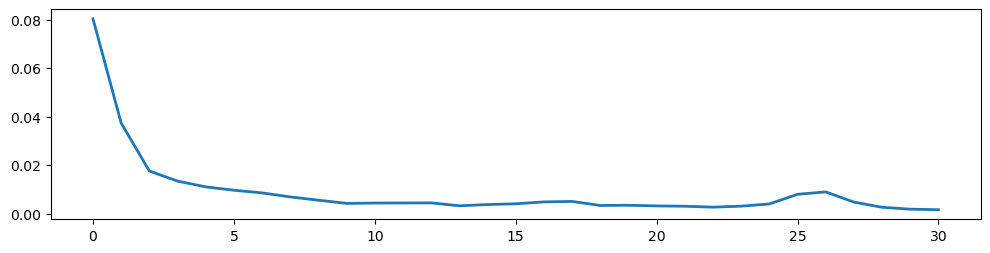

In [112]:
cost=[]
epoch=31
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          # farward pass
          ypred= model(xbatch)
          model.zero_grad()
          model.backward(y_true=ybatch,y_pred=ypred) 
          model.step()
          er.append(model.MSE(ybatch,ypred)) 

     loss= torch.mean(torch.tensor(er))
     cost.append(loss)
     if iter%5==0:
          # validation
          y_pred=[]
          y_true=[]
          for i,(xbatch,ybatch) in enumerate(valid_loader):
               # farward pass
               ypred= model(xbatch)
               ypred= torch.argmax(ypred,dim=1)
               y_pred.extend(ypred.numpy())
               y_true.extend(torch.argmax(ybatch,dim=1).numpy())
               
          y_pred= np.array(y_pred)
          y_true= np.array(y_true)
          accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
          print(f'Loss({iter}): {cost[iter]:.6f} **** Valid Acc:{accuracy:.3f}%')

cost=torch.tensor(cost)
plt.figure(figsize=(12, 6))
plt.subplot(2,1,1)
plt.plot(cost,linewidth=2)
plt.show()

**Validate trained Neural Netwrok**

Total accuracy:96.852%
accuracy0:100.000%
accuracy1:91.935%
accuracy2:98.077%
accuracy3:98.387%
accuracy4:100.000%
accuracy5:95.918%
accuracy6:93.333%
accuracy7:100.000%
accuracy8:92.453%
accuracy9:97.872%


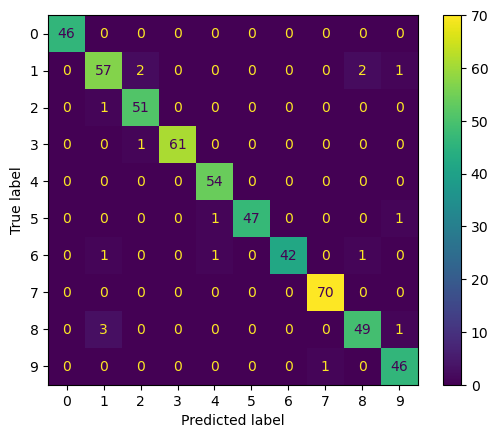

In [113]:
# validation
y_pred=[]
y_true=[]
for i,(xbatch,ybatch) in enumerate(test_loader):
    # farward pass
    ypred= model(xbatch)
    ypred= torch.argmax(ypred,dim=1)
    y_pred.extend(ypred.numpy())
    y_true.extend(torch.argmax(ybatch,dim=1).numpy())
    
y_pred= np.array(y_pred)
y_true= np.array(y_true)

from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
#%% test trained Neural Network
C= confusion_matrix(y_true,y_pred)
# print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
print(f'Total accuracy:{accuracy:.3f}%')

for i in range(C.shape[0]):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()